## Protonation state for single molecule

In [ ]:
from pkasso import protonate

name = "mymolecule"
smiles = r"OC(=O)C(c1ccc(O)cc1)CNCCN"
pH = 7.0

# Include microstates with probability of 20% compared to most probable microstate
# Select cutoff_export = 1. to only output the most likely microstate
cutoff_export = 0.2

# protonate accepts a smiles string or an rdkit Mol as input
smiles_out, mols_out = protonate(smiles, name=name, pH=pH, cutoff_export=cutoff_export)
print(smiles_out)

In [ ]:
from pkasso.postprocess import draw_mols

draw_mols(mols_out)

In [ ]:
# Retrieve properties from rdkit mol objects

names = [mol.GetProp("_Name") for mol in mols_out]
print(names)
probabilities = [float(mol.GetProp("Probability")) for mol in mols_out]
print(probabilities)
net_charges = [float(mol.GetProp("net_charge")) for mol in mols_out]
print(net_charges)

In [ ]:
from pkasso.postprocess import save_sdf

### Optionally save all microstates in one sdf file
save_sdf(mols_out, f"{name}.sdf")

## Single protonation state with mixed model (MolGpKa + Uni-pKa)

In [ ]:
from pkasso import protonate

name = "mymolecule"
smiles = r"OC(=O)C(c1ccc(O)cc1)CNCCN"
pH = 7.0

model = {
    "molgpka": {},
    "unipka": {
        "folds": (1,2,),
        "gpu": True,
    },
}

# Include microstates with probability of 20% compared to most probable microstate
# Select cutoff_export = 1. to only output the most likely microstate
cutoff_export = 0.2

# protonate accepts a smiles string or an rdkit Mol as input
smiles_out, mols_out = protonate(
    smiles,
    name=name,
    pH=pH,
    cutoff_export=cutoff_export,
    model=model)
print(smiles_out)

## Batch process molecules

In [ ]:
from pkasso import protonate

batch_input = [
    "OC(=O)C(c1ccc(O)cc1)CNCCN",
    "C1CNCCN(C1)S(=O)(=O)C2=CC=CC3=C2C=CN=C3",
    "C1=C(NC=N1)CCN",
]

# Use a simple for loop to batch protonate

smiles_batch = []
mols_batch = []

for smiles in batch_input:
    smiles_out, mols_out = protonate(smiles, pH=7.0, cutoff_export=0.2)
    print(smiles_out)
    smiles_batch.append(smiles_out)
    mols_batch.append(mols_out)

In [ ]:
from pkasso.postprocess import draw_mols

# draw microstates of first molecule
mols = mols_batch[0]
draw_mols(mols)

In [ ]:
from pkasso.postprocess import save_sdf

# Save microstates to sdf files
names = ["mymolecule", "fasudil", "histamine"]

for mols, name in zip(mols_batch, names):
    save_sdf(mols, f"{name}.sdf")

## Run pH scan for single molecule

/home/sobuelow/miniconda3/envs/test_pkasso/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Macro-pKa values:
pKa1 | 2 --> 1 | 3.317
pKa2 | 1 --> 0 | 6.178
pKa3 | 0 --> -1 | 9.173
pKa4 | -1 --> -2 | 10.044


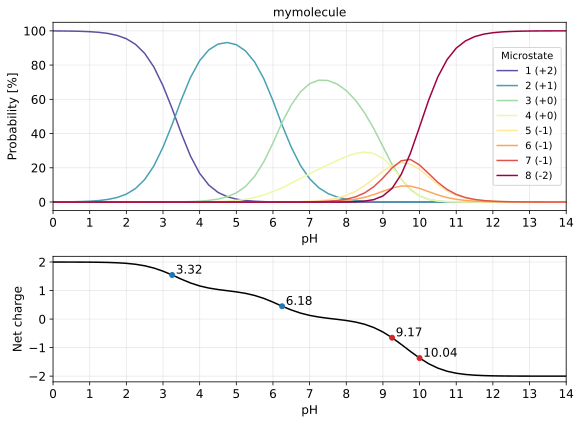

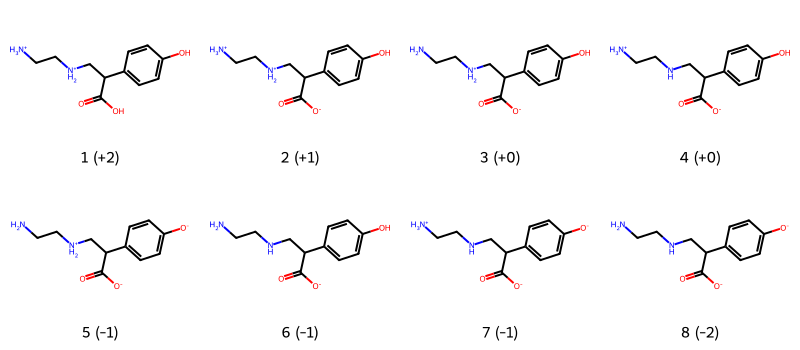

In [1]:
%config InlineBackend.figure_format = 'svg'
from pkasso import scan_pH
from IPython.display import display

smiles = r"OC(=O)C(c1ccc(O)cc1)CNCCN"
name = "mymolecule"

scan = scan_pH(
    smiles,
    name=name,
)

scan.print_macro_pkas()

display(scan.plot_scan())
display(scan.plot_mols())

('NCC[NH2+]CC(C(=O)[O-])c1ccc(O)cc1', '[NH3+]CCNCC(C(=O)[O-])c1ccc(O)cc1', 'NCC[NH2+]CC(C(=O)[O-])c1ccc([O-])cc1', '[NH3+]CCNCC(C(=O)[O-])c1ccc([O-])cc1')


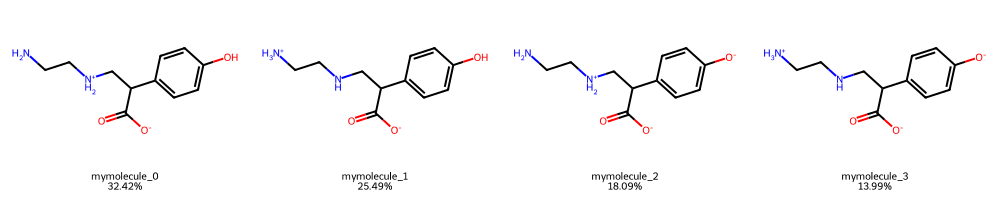

In [3]:
# The pH-dependent protonation states can be retrieved from the scan 
# Use the scan.molecule_at() function for the chosen pH:

from pkasso.postprocess import draw_mols

pH = 9
microstates_at_pH = scan.molecule_at(pH)

print(microstates_at_pH.smiles)

draw_mols(microstates_at_pH.mols)

In [ ]:
#